# Initial-condition effects

For fixed $L$, $d$, and $c$, the panels summarize each curve $p^*(f_T)$ over the $(p_0, P_0)$ plane. Missing simulations are left blank.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

notebook_dir = Path.cwd()
if not (notebook_dir / 'src').is_dir():
    notebook_dir = notebook_dir / 'jupyter'
sys.path.insert(0, str(notebook_dir / 'src'))

from src.initial_conditions import (
    get_initial_condition_combinations,
    prepare_initial_condition_maps,
)

plt.style.use(notebook_dir / 'properties.mplstyle')

## Data preparation

In [12]:
L = 1024
dim = 2
c = 0.1
nc = 1
rho = 1.0
order = 0

all_combinations = [(i, j) for i in np.arange(0.1,1.1,0.1) for j in np.arange(0.1,1.1,0.1)]
df = pd.read_csv(notebook_dir.parent / 'SOP_data' / 'all_data_dynamic.dat', sep=r'\s+')

combinations = get_initial_condition_combinations(
    df, L, dim=dim, c=c, nc=nc, rho=rho, order=order
)
#print(f'{len(combinations)} unique (p0, P0) combinations')
#combinations
remaining = [comb for comb in combinations if comb not in all_combinations]
remaining

[(0.1, 0.3),
 (0.2, 0.3),
 (0.3, 0.1),
 (0.3, 0.2),
 (0.3, 0.3),
 (0.4, 0.3),
 (0.4, 0.7),
 (0.5, 0.3),
 (0.5, 0.7),
 (0.6, 0.3),
 (0.6, 0.7),
 (0.7, 0.1),
 (0.7, 0.2),
 (0.7, 0.3),
 (0.7, 0.4),
 (0.7, 0.5),
 (0.7, 0.6),
 (0.7, 0.7),
 (0.7, 0.8),
 (0.7, 0.9),
 (0.7, 1.0),
 (0.8, 0.3),
 (0.8, 0.7),
 (0.9, 0.3),
 (0.9, 0.7),
 (1.0, 0.3)]

In [13]:
prepared = prepare_initial_condition_maps(
    df,
    L,
    dim=dim,
    c=c,
    nc=nc,
    rho=rho,
    order=order,
    min_percolating_samples=5,
    require_all_samples=True,
    p_star_min=0.0,
    p_star_max=0.9,
    f_T_max=0.4,
)

display(prepared['node']['summary'].head())
display(prepared['bond']['summary'].head())

,type_perc,p0,P0,f_T_min,f_T_max,delta_f_T,p_star_min,f_T_at_p_star_min,p_star_min_err,n_f_T
0,node,0.2,0.3,0.177895,0.300000,0.122105,0.598613,0.177895,0.000048,8
1,node,0.3,0.1,0.162632,0.284737,0.122105,0.597912,0.162632,0.000053,8
2,node,0.3,0.2,0.193158,0.300000,0.106842,0.599392,0.193158,0.000043,8
3,node,0.3,0.3,0.162632,0.300000,0.137368,0.598037,0.162632,0.000050,10
4,node,0.4,0.1,0.177895,0.300000,0.122105,0.598593,0.177895,0.000033,9


,type_perc,p0,P0,f_T_min,f_T_max,delta_f_T,p_star_min,f_T_at_p_star_min,p_star_min_err,n_f_T
0,bond,0.2,0.1,0.238947,0.3,0.061053,0.505142,0.238947,0.000036,4
1,bond,0.2,0.2,0.223684,0.3,0.076316,0.504824,0.223684,0.000039,6
2,bond,0.2,0.3,0.238947,0.3,0.061053,0.505277,0.238947,0.000037,5
3,bond,0.3,0.1,0.223684,0.3,0.076316,0.504837,0.223684,0.000042,6
4,bond,0.3,0.2,0.223684,0.3,0.076316,0.504793,0.223684,0.000038,6


## Heatmaps

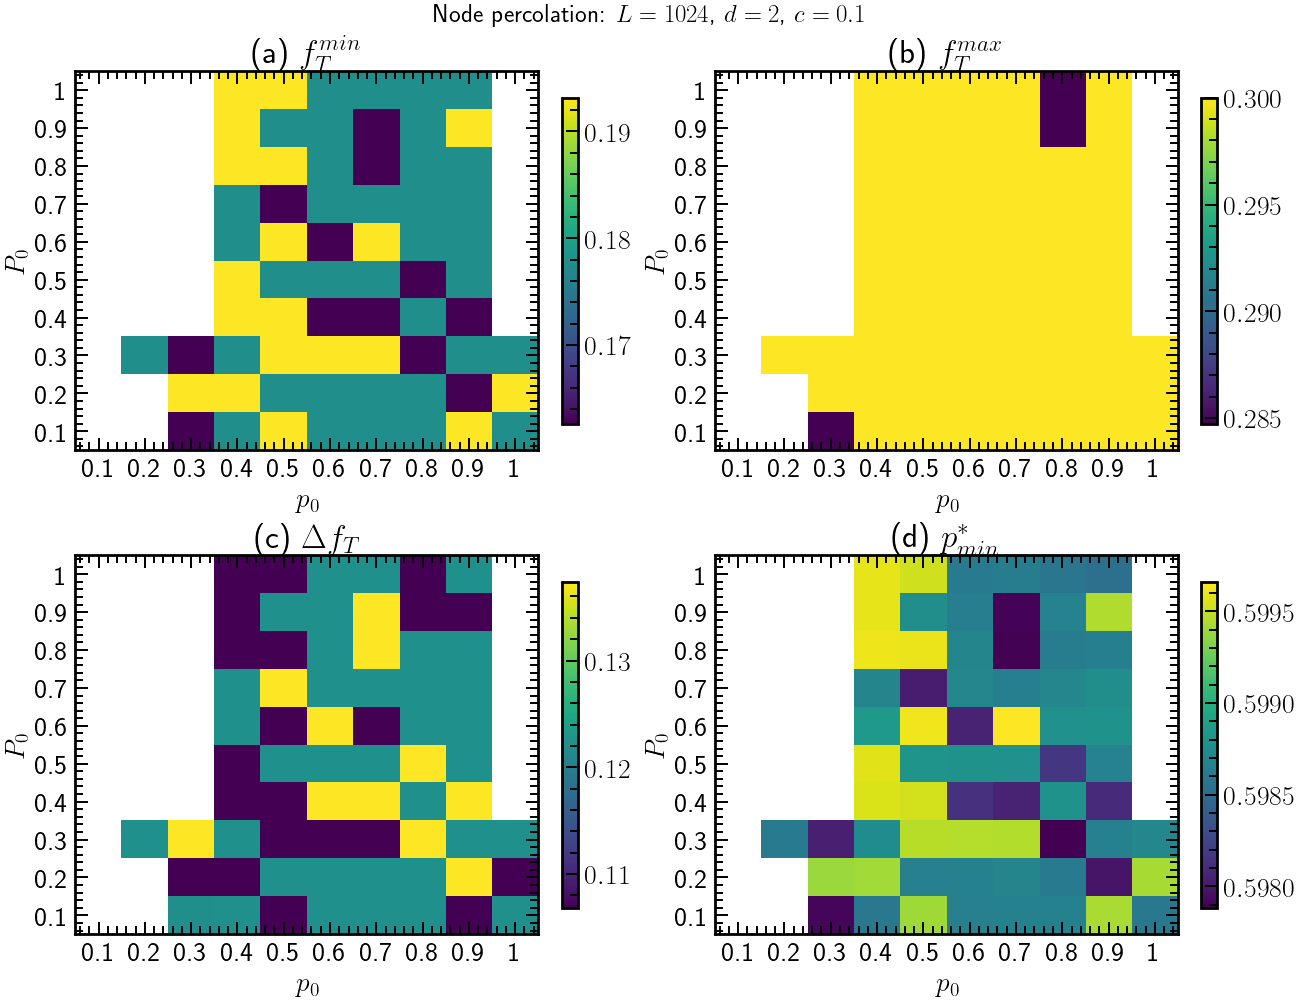

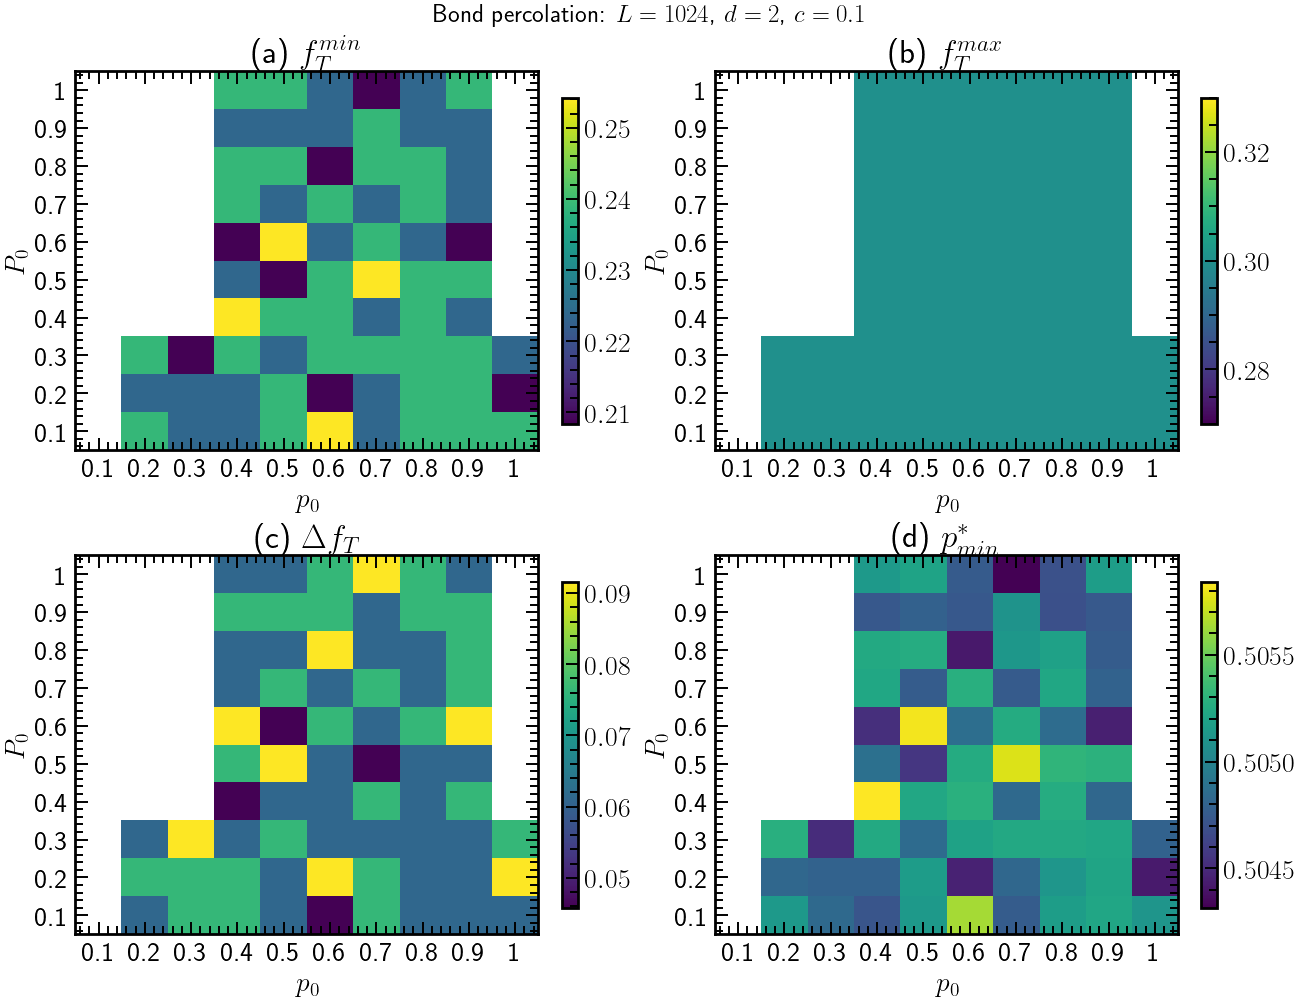

In [14]:
metrics = [
    ('f_T_min', r'(a) $f_T^{min}$'),
    ('f_T_max', r'(b) $f_T^{max}$'),
    ('delta_f_T', r'(c) $\Delta f_T$'),
    ('p_star_min', r'(d) $p^*_{min}$'),
]

for type_perc in ('node', 'bond'):
    fig, axes = plt.subplots(2, 2, figsize=(13, 10), constrained_layout=True)

    for ax, (metric, title) in zip(axes.flat, metrics):
        matrix = prepared[type_perc]['maps'][metric]
        masked_values = np.ma.masked_invalid(matrix.to_numpy(dtype=float))
        image = ax.imshow(masked_values, origin='lower', aspect='auto', cmap='viridis')

        ax.set_xticks(np.arange(len(matrix.columns)), labels=[f'{x:g}' for x in matrix.columns])
        ax.set_yticks(np.arange(len(matrix.index)), labels=[f'{y:g}' for y in matrix.index])
        ax.set_xlabel(r'$p_0$')
        ax.set_ylabel(r'$P_0$')
        ax.set_title(title)
        fig.colorbar(image, ax=ax, shrink=0.86)

    fig.suptitle(
        rf'{type_perc.capitalize()} percolation: $L={L}$, $d={dim}$, $c={c}$',
        fontsize=18,
    )
    plt.show()